![Kenya Food Price Early Warning System](images/banner.png)

# Kenya Food Price Early Warning System

Forecasting staple food prices across Kenyan markets to give farmers, traders, and food security actors the early signal they currently lack.

## 1. Business Understanding

### 1.1 Background

Kenya's food markets experience recurring price volatility that is structural rather than incidental. Staple commodities such as maize and beans regularly swing between price spikes and crashes across the country's markets, driven by a combination of seasonal harvest cycles, rainfall variability, and fragmented market information. These swings are not isolated shocks; they are a persistent feature of the agricultural economy, and they impose real costs on both ends of the supply chain.

Smallholder farmers frequently sell too early, often under financial pressure, missing the benefit of a later price rise, or they sell too late and absorb the loss of a price crash. On the consumer side, the same volatility worsens food insecurity for urban and rural households already living close to the margin, since a price spike in a staple commodity disproportionately affects the poorest families. County agricultural offices, national drought monitoring bodies, and humanitarian organizations that operate in this space currently rely on lagging, manual, and fragmented indicators, which limits their ability to intervene before a crisis has already taken hold.

This project addresses that information gap directly. Rather than producing a single national average or a static report, it proposes a forecasting and early warning system built at the market and commodity level, so that the people who make real time decisions, buying, selling, storing, or intervening, have a forward looking signal rather than a historical one.

### 1.2 Problem Statement

Smallholder farmers, traders, and the institutions that support them cannot currently anticipate price spikes or crashes for staple commodities such as maize and beans in Kenyan markets. This absence of forward looking price intelligence has measurable consequences.

Farmers sell at the wrong time relative to the true price cycle, either too early under financial pressure or too late after a crash has already begun, eroding household income and reinforcing rural poverty. Traders and intermediaries carry inventory risk without a reliable signal of where prices are heading, which distorts both their buying behavior and the prices ultimately passed on to consumers. County and national food security institutions, including the National Drought Management Authority, operate reactively, deploying relief and strategic reserves only after a crisis has become visible rather than while it is still preventable.

The core problem is therefore not a lack of historical price data, since datasets such as the WFP Kenya food prices series are publicly available and well maintained. The problem is the absence of a system that converts that historical data, combined with relevant exogenous signals such as weather, into a forward looking, market specific forecast with a built in mechanism for flagging when reality is beginning to diverge from expectation.

### 1.3 Business Objectives

The project is guided by the following business objectives, each of which maps to a concrete beneficiary need identified in the stakeholder analysis.

**Objective 1: Provide forward looking price visibility.**
Deliver a two to four week price forecast, per market and per commodity, so that farmers, traders, and cooperatives can make selling and buying decisions based on expected future prices rather than only the current spot price.

**Objective 2: Detect emerging anomalies before they become crises.**
Build a mechanism that flags when actual prices are beginning to diverge from the model's expectation, giving institutional actors, such as county agricultural offices, NDMA, and NCPB, a lead time window to act before a shortage or price shock becomes acute.

**Objective 3: Democratize market intelligence.**
Reduce the information asymmetry between smallholder farmers and better informed intermediaries by making the same forward looking trend data available to both, through an accessible, interactive dashboard rather than a static or technical report.

**Objective 4: Support evidence based institutional decision making.**
Give county offices, NDMA, NCPB, and humanitarian organizations a quantitative, defensible basis for decisions such as reserve release timing, subsidy targeting, and anticipatory cash disbursement, replacing reactive and anecdotal decision making with data driven triggers.

**Objective 5: Demonstrate a reproducible, deployable pipeline.**
Produce a documented data pipeline joining price and weather data, together with a deployed interactive dashboard, satisfying the capstone's mandatory deployment requirement with a genuinely usable tool rather than a static analysis.

### 1.4 Stakeholder Analysis

The system serves a wide range of beneficiaries across the food value chain, from individual farmers to national institutions. The table below summarizes the primary stakeholder groups, their core objective, and the central problem the system addresses for each. A full stakeholder breakdown, including specific benefit mappings, is maintained separately in the project's business documentation and informed the feature and output design described later in this notebook.

| Stakeholder Group | Core Objective | Key Problem Addressed |
|---|---|---|
| Smallholder Farmers and Cooperatives | Maximize net income per harvest while minimizing the risk of distress selling | Asymmetric market information relative to traders, and pressure to sell immediately after harvest |
| Traders and Market Intermediaries | Maximize margins by optimizing inventory turnover and timing | Buying at price peaks, overstocking, and blindness to spatial arbitrage opportunities |
| County Agricultural Offices and NDMA | Maintain food security stability through timely, accurate early warning | Reactive governance and uniform budget allocation that does not reflect localized risk |
| NGOs and Humanitarian Actors | Maximize the purchasing power of cash transfers and optimize procurement timing | Disbursing cash after prices have already risen, and procuring supplies at price peaks |
| National Cereals and Produce Board | Execute price stabilization and strategic reserve management efficiently | Releasing reserves too late, and competitive buying that drives prices up further |
| Urban Poor and Consumers | Protect household purchasing power against sudden price spikes | Vulnerability to price shocks with no advance warning to adjust household budgeting |
| Food Processors and Millers | Secure raw materials at stable, predictable prices to protect margins | Procuring without forward price visibility, leading to unprofitable fixed price contracts |

Across every stakeholder group, the same underlying need recurs in different forms: a forward looking, market specific price signal, combined with a clear trigger for when that signal indicates a meaningful departure from the expected trend. This shared need is what the forecasting and anomaly detection components of the system are designed to satisfy.

### 1.6 Data Mining Goals

The business objectives above translate into the following concrete data science goals.

Build a time series forecasting model, using Prophet as a baseline and an LSTM as a comparison model, that predicts commodity prices two to four weeks ahead at the individual market level, incorporating lagged weather variables, specifically rainfall and temperature, as exogenous features. Engineer a data pipeline that cleanly joins the WFP Kenya food prices dataset to NASA POWER weather data using market location, mapped to latitude and longitude, and date as the join keys. Develop a residual based anomaly detection layer that compares actual observed prices against the model's forecast and flags statistically significant divergence as an early warning signal. Produce a rigorous model comparison between the Prophet baseline and the LSTM alternative, evaluated using MAE and MAPE broken down by commodity and market, to determine which approach performs better under which conditions. Deploy the complete pipeline and forecast output as an interactive Streamlit dashboard, satisfying the project's mandatory deployment requirement.

### 1.7 Data Mining Success Criteria

From a technical standpoint, the modeling work will be considered successful if the forecasting models achieve a MAPE that represents a clear improvement over a naive seasonal baseline across the majority of market and commodity combinations tested. The anomaly detection threshold should be calibrated so that it captures genuine, previously observed historical price shocks in backtesting, without triggering excessively on ordinary short term price noise. The data pipeline should run end to end without manual intervention once source data is refreshed, and the join between price and weather data should retain the large majority of records without significant data loss. Finally, the deployed dashboard should load and update correctly for at least the primary set of markets and commodities selected for the final submission, demonstrating that the system functions as a genuinely usable tool rather than a one time analysis.

### 1.8 Project Plan Overview

The project follows a five week timeline aligned with the capstone's CRISP-DM structure.

In week one, the team pitches the project, pulls and inspects the HDX price dataset and a sample NASA POWER API call, and confirms that the market name to coordinate join is clean and reliable. In week two, the full data pipeline is built, including cleaning, joining, feature engineering, and the construction of lagged weather features, alongside exploratory data analysis at the commodity and market level. In week three, the Prophet baseline model is built and backtested, the LSTM model is developed in parallel, and the first version of the Streamlit dashboard is deployed. In week four, the model comparison is finalized, the anomaly detection and alert logic is implemented, the CRISP-DM report is written, and feedback from the technical mentor is incorporated. In week five, the dashboard is polished, a WhatsApp alert simulation is added if time permits, and the final demonstration is prepared.

This phased structure ensures that a working, deployed system exists well before the final week, with the remaining time dedicated to refinement rather than first time integration.

## 2. Data Understanding

This phase establishes a thorough working knowledge of both primary data sources before any cleaning, joining, or modeling begins. Two datasets are examined: the WFP Kenya food prices dataset sourced from HDX, and daily meteorological data retrieved from the NASA POWER API. A third supporting file, mapping market names to geographic coordinates, is also assessed since it is the join key that ties price data to weather data.

The objective of this phase is not only to describe the data, but to surface early evidence for or against the hypotheses formed during Business Understanding, so that the modeling phase begins with informed expectations rather than assumptions.

### 2.1 Data Collection

Two data sources are used, both publicly accessible without authentication, satisfying the capstone's requirement to avoid access barriers.

| Data Source | Access Method | Authentication |
|---|---|---|
| WFP Kenya Food Prices (HDX) | Direct CSV download | None required |
| NASA POWER API | REST API, JSON or CSV response | None required |

The food prices file provides the target variable, historical price observations by market, commodity, and date. The NASA POWER API supplies the exogenous weather variables, specifically rainfall and temperature, used to improve forecast accuracy beyond what price history alone can achieve. A record of the exact extraction date and file version is kept below, since both sources update periodically and reproducibility depends on knowing precisely which snapshot was used.

In [3]:
# import necessary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime

# make wide tables and columns readable within the notebook
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Record the extraction timestamp for reproducibility.
extraction_date = datetime.now().strftime("%Y-%m-%d")
print(f"Data extraction date recorded: {extraction_date}")

Data extraction date recorded: 2026-08-22


In [4]:
# Load the WFP Kenya food prices dataset.

hdx_url = "https://data.humdata.org/dataset/e0d3fba6-f9a2-45d7-b949-140c455197ff/resource/517ee1bf-2437-4f8c-aa1b-cb9925b9d437/download/wfp_food_prices_ken.csv"

# Read the dataset
prices_raw = pd.read_csv(hdx_url)

# Inspect the first few rows
prices_raw.head(3)

RemoteDisconnected: Remote end closed connection without response

In [ ]:
# WFP HDX exports place a description row as the first data row (e.g. "#date", "#adm1+name", "#value+usd" etc). 
# This checks for and removes it so the dataframe contains only genuine price observations.

if prices_raw.iloc[0].astype(str).str.startswith("#").any():
    prices = prices_raw.iloc[1:].reset_index(drop=True)
    print("Detected and removed a units/description header row.")
else:
    prices = prices_raw.copy()
    print("No units row detected, dataframe used as is.")

# Convert date and price columns to proper types now that the units row is gone
prices["date"] = pd.to_datetime(prices["date"], errors="coerce")
prices["price"] = pd.to_numeric(prices["price"], errors="coerce")
if "usdprice" in prices.columns:
    prices["usdprice"] = pd.to_numeric(prices["usdprice"], errors="coerce")

print(f"Rows: {prices.shape[0]}, Columns: {prices.shape[1]}")
print(f"Date range: {prices['date'].min()} to {prices['date'].max()}")

No units row detected, dataframe used as is.
Rows: 27384, Columns: 16
Date range: 2006-01-15 00:00:00 to 2026-08-15 00:00:00


In [ ]:
# Test a single NASA POWER API call for Nairobi coordinates before scaling up
# to all markets. This confirms the API is reachable and the response structure
# matches expectations, before building the full weather retrieval pipeline.

nairobi_lat, nairobi_lon = -1.2864, 36.8172

power_url = "https://power.larc.nasa.gov/api/temporal/daily/point"
params = {
    "parameters": "T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M",  # temperature, rainfall, humidity
    "community": "ag",          # agroclimatology community, most relevant for crop related forecasting
    "longitude": nairobi_lon,
    "latitude": nairobi_lat,
    "start": "20240101",
    "end": "20240131",
    "format": "JSON",
}

response = requests.get(power_url, params=params, timeout=30)
print(f"Status code: {response.status_code}")

power_sample = response.json()

# Extract the parameter dictionary to confirm structure and preview one variable
sample_params = power_sample["properties"]["parameter"]
print("Parameters returned:", list(sample_params.keys()))
print("Sample PRECTOTCORR values:", list(sample_params["PRECTOTCORR"].items())[:5])

Status code: 200
Parameters returned: ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']
Sample PRECTOTCORR values: [('20240101', 0.31), ('20240102', 1.38), ('20240103', 0.28), ('20240104', 1.51), ('20240105', 1.56)]


### 2.2 Data Description

With both sources confirmed accessible, this section documents their exact structure. Understanding the grain of each dataset, meaning the level at which one row represents one real world observation, is essential before any join or aggregation decision is made in the Data Preparation phase.

The price dataset is at the market, commodity, date grain, meaning each row is one commodity's price at one market on one date. The weather dataset, once retrieved per market coordinate, is at the location, date grain, with one row per day per set of coordinates.

In [ ]:
# Build a structured data dictionary documenting every column, its data type,
# and a short description. This becomes the authoritative reference table
# in the report rather than relying on memory of the raw CSV structure.

data_dictionary = pd.DataFrame({
    "column": prices.columns,
    "dtype": [str(prices[col].dtype) for col in prices.columns],
    "n_unique": [prices[col].nunique() for col in prices.columns],
    "n_missing": [prices[col].isna().sum() for col in prices.columns],
    "pct_missing": [(prices[col].isna().mean() * 100).round(2) for col in prices.columns],
})

data_dictionary

,column,dtype,n_unique,n_missing,pct_missing
0,date,datetime64[us],248,0,0.00
1,admin1,str,7,68,0.25
2,admin2,str,27,68,0.25
3,market,str,226,0,0.00
4,market_id,int64,226,0,0.00
5,latitude,float64,182,68,0.25
6,longitude,float64,184,68,0.25
7,category,str,8,0,0.00
8,commodity,str,51,0,0.00
9,commodity_id,int64,51,0,0.00


In [ ]:
# Descriptive statistics for the numeric fields, price and usdprice.
# This gives an immediate sense of scale, spread, and potential outliers
# before any visual inspection.

prices[["price", "usdprice"]].describe()

,price,usdprice
count,27384.000000,27384.000000
mean,1314.192665,11.988443
std,2591.381339,22.997800
min,5.000000,0.039000
25%,70.000000,0.610000
50%,130.000000,1.030000
75%,1000.750000,9.292500
max,19800.000000,184.820000


In [ ]:
# Confirm the grain of the dataset: one row should represent a unique
# combination of market, commodity, date, and price type (retail or wholesale).
# Duplicate combinations would indicate either genuine repeated reporting
# or a data quality issue worth investigating.

grain_columns = ["date", "market", "commodity", "pricetype"]
duplicate_count = prices.duplicated(subset=grain_columns).sum()

print(f"Duplicate rows at (date, market, commodity, pricetype) grain: {duplicate_count}")
print(f"Unique markets: {prices['market'].nunique()}")
print(f"Unique commodities: {prices['commodity'].nunique()}")
print(f"Unique admin1 regions: {prices['admin1'].nunique()}")

Duplicate rows at (date, market, commodity, pricetype) grain: 0
Unique markets: 226
Unique commodities: 51
Unique admin1 regions: 7


### 2.3 Exploratory Data Analysis

Exploratory analysis is organized in three stages. Univariate analysis examines each variable individually, establishing baseline distributions and coverage. Bivariate analysis examines relationships between pairs of variables, most importantly the relationship between weather and price, since this is the foundation of the forecasting model's exogenous features. Multivariate and geographic analysis then considers how these patterns vary across regions and commodities simultaneously.

Throughout this section, maize and beans are treated as priority commodities, since they carry the greatest weight in the business objectives defined earlier, though the same analysis pattern generalizes to any commodity present in the dataset.

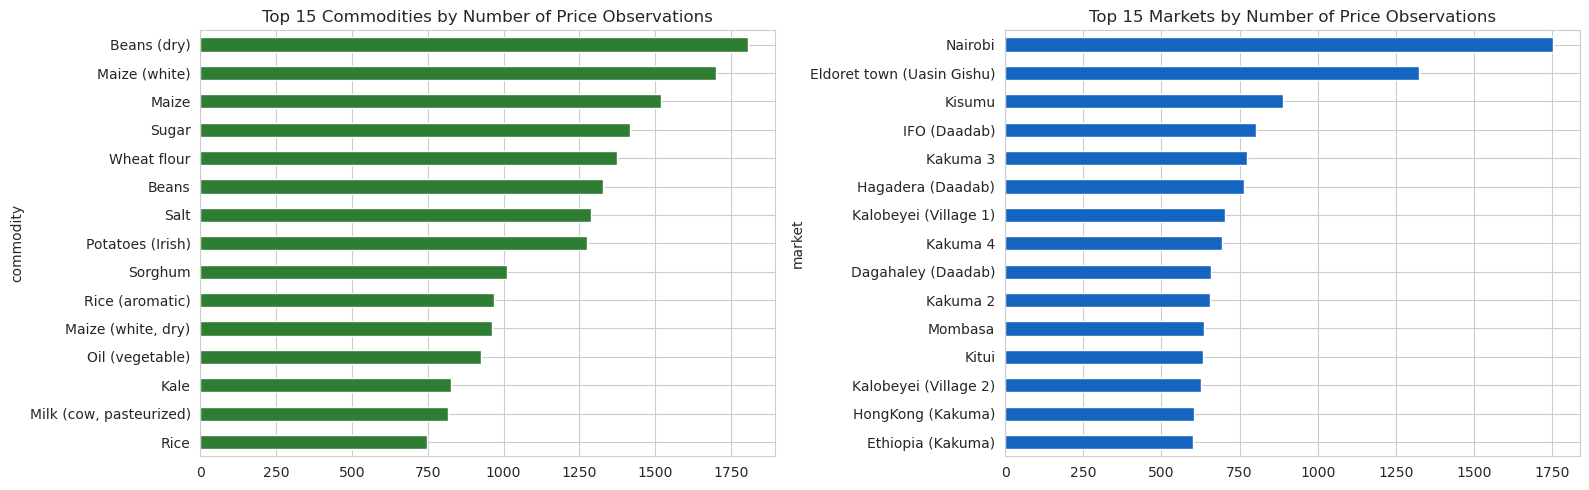

In [ ]:
# Understand which commodities and markets have the most complete data.
# This directly informs which commodity-market pairs are viable candidates
# for individual forecasting models later in the project.

commodity_counts = prices["commodity"].value_counts().head(15)
market_counts = prices["market"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

commodity_counts.plot(kind="barh", ax=axes[0], color="#2E7D32")
axes[0].set_title("Top 15 Commodities by Number of Price Observations")
axes[0].invert_yaxis()

market_counts.plot(kind="barh", ax=axes[1], color="#1565C0")
axes[1].set_title("Top 15 Markets by Number of Price Observations")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

/tmp/ipykernel_9494/257609382.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="commodity", y="price", palette=["#2E7D32", "#8D6E63"])


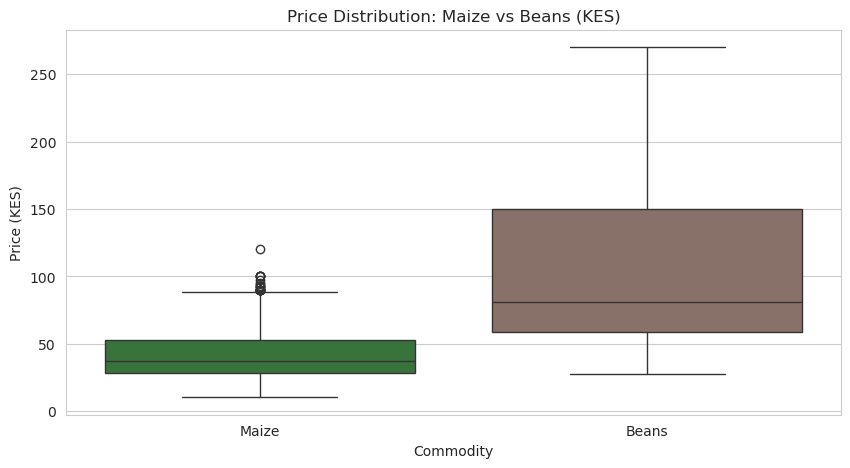

In [ ]:
# Examine the distribution of prices for the two priority commodities.
# Boxplots reveal both typical price range and the presence of outliers
# that may need investigation or capping in the Data Preparation phase.

priority_commodities = ["Maize", "Beans"]
subset = prices[prices["commodity"].isin(priority_commodities)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=subset, x="commodity", y="price", palette=["#2E7D32", "#8D6E63"])
plt.title("Price Distribution: Maize vs Beans (KES)")
plt.ylabel("Price (KES)")
plt.xlabel("Commodity")
plt.show()

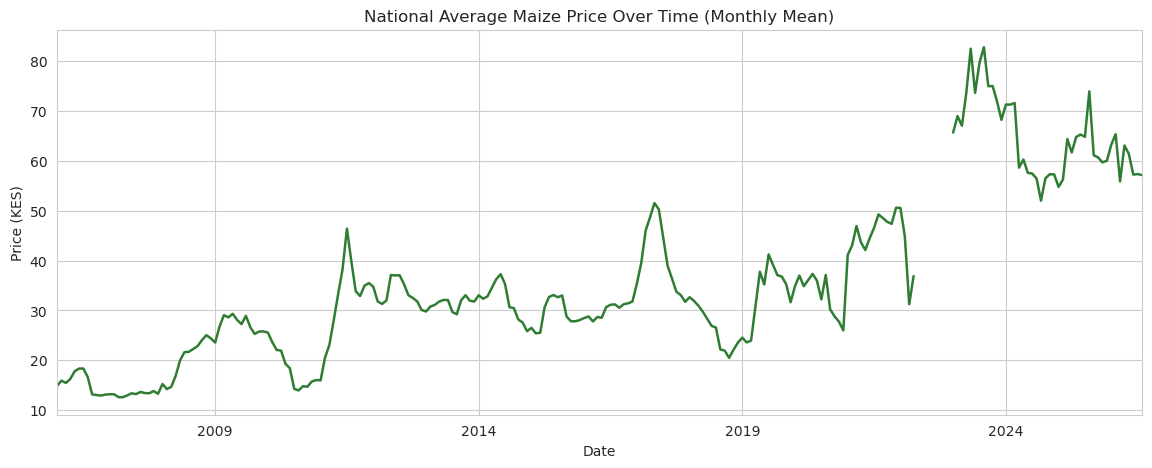

In [ ]:
# Plot the average national price trend for maize over the full time range.
# This is the primary time series the forecasting model will eventually learn,
# so understanding its long run shape, trend, and volatility here is essential.

maize = prices[prices["commodity"] == "Maize"].copy()
maize_monthly = maize.groupby(pd.Grouper(key="date", freq="ME"))["price"].mean()

plt.figure(figsize=(14, 5))
maize_monthly.plot(color="#2E7D32", linewidth=1.8)
plt.title("National Average Maize Price Over Time (Monthly Mean)")
plt.ylabel("Price (KES)")
plt.xlabel("Date")
plt.show()

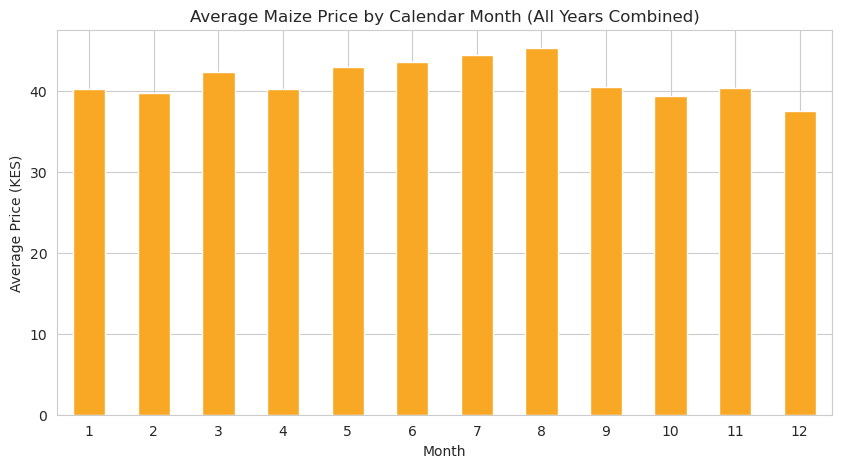

In [ ]:
# Aggregate maize prices by calendar month, across all years, to check for
# a recurring seasonal pattern tied to Kenya's harvest cycle. This directly
# tests Hypothesis H1 from the Business Understanding phase.

maize["month"] = maize["date"].dt.month
seasonal_avg = maize.groupby("month")["price"].mean()

plt.figure(figsize=(10, 5))
seasonal_avg.plot(kind="bar", color="#F9A825")
plt.title("Average Maize Price by Calendar Month (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Average Price (KES)")
plt.xticks(rotation=0)
plt.show()

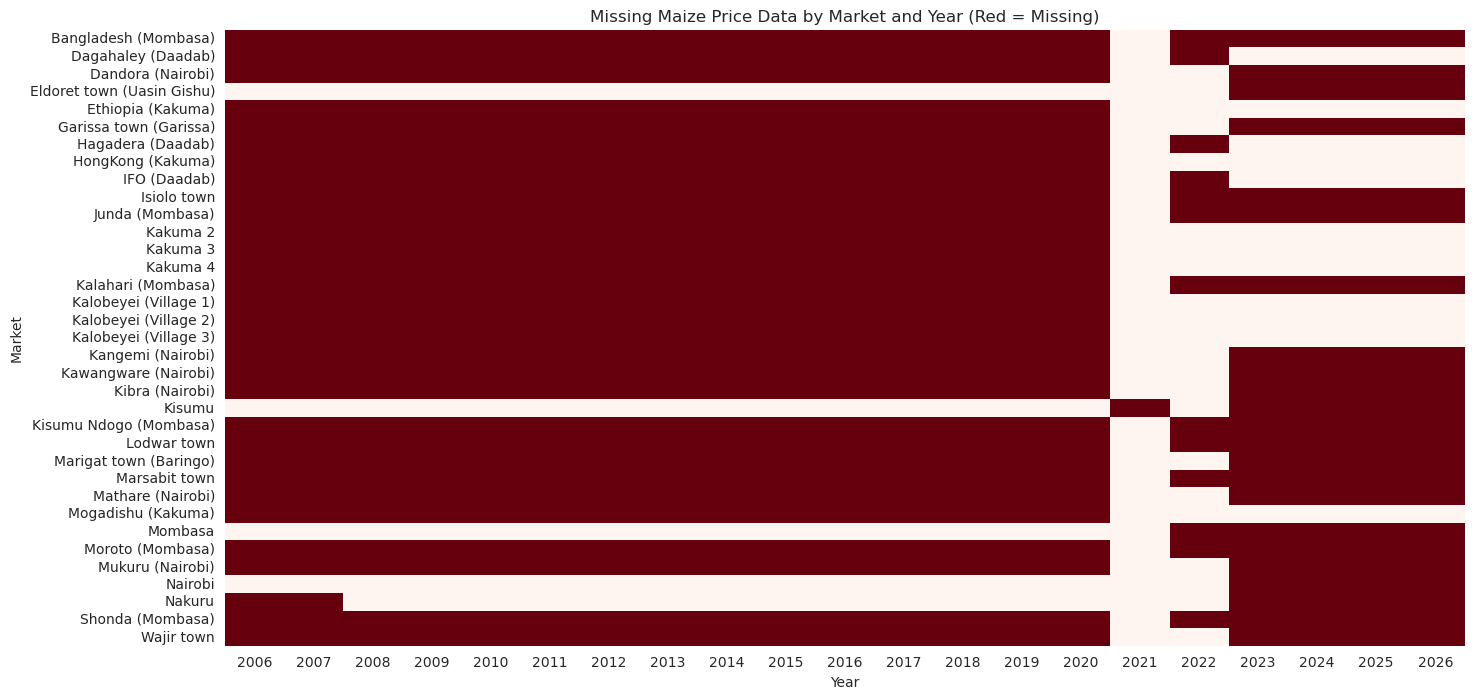

In [ ]:
# Visualize missingness across markets for the priority commodities.
# A market-month pivot table makes gaps immediately visible, which is more
# informative than a single aggregate missing percentage.

pivot_check = maize.pivot_table(
    index="market",
    columns=maize["date"].dt.year,
    values="price",
    aggfunc="mean"
)

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_check.isna(), cbar=False, cmap="Reds")
plt.title("Missing Maize Price Data by Market and Year (Red = Missing)")
plt.xlabel("Year")
plt.ylabel("Market")
plt.show()

In [ ]:
# Flag statistical outliers in the price series using the interquartile range
# method. These are candidates for manual review, since they may represent
# genuine price shocks or data entry errors, a distinction that matters for
# both anomaly detection design and data cleaning decisions.

q1 = maize["price"].quantile(0.25)
q3 = maize["price"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = maize[(maize["price"] < lower_bound) | (maize["price"] > upper_bound)]

print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}] KES")
print(f"Outlier observations detected: {len(outliers)} out of {len(maize)}")
outliers[["date", "market", "price"]].sort_values("price", ascending=False).head(10)

IQR bounds: [-8.14, 88.89] KES
Outlier observations detected: 23 out of 1518


,date,market,price
23210,2023-08-15,Dagahaley (Daadab),120.00
23845,2024-01-15,Dagahaley (Daadab),100.00
22832,2023-05-15,Ethiopia (Kakuma),100.00
23370,2023-09-15,Ethiopia (Kakuma),100.00
23381,2023-09-15,HongKong (Kakuma),100.00
24118,2024-03-15,HongKong (Kakuma),100.00
24676,2024-08-15,Dagahaley (Daadab),97.50
22865,2023-05-15,Kakuma 3,95.00
24071,2024-03-15,Dagahaley (Daadab),94.41
23177,2023-07-15,Kalobeyei (Village 2),93.13


### 2.4 Weather Data Exploration

With price patterns established, the same rigor is applied to the weather data retrieved from NASA POWER. Rainfall and temperature are the two variables most directly tied to agricultural output, and by extension to price formation several months later. Kenya's known bimodal rainfall pattern, long rains from March to May and short rains from October to December, provides a natural benchmark against which the retrieved data can be validated.

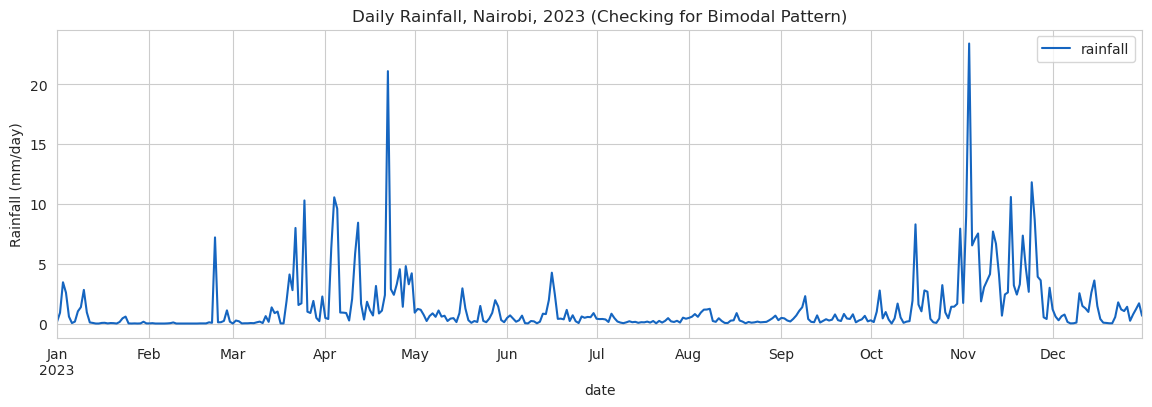

In [ ]:
# Retrieve a full year of daily weather data for Nairobi to examine seasonal
# rainfall and temperature patterns, and to visually confirm the data matches
# Kenya's known bimodal rainfall pattern before scaling to all markets.

params_full_year = {
    "parameters": "T2M,PRECTOTCORR",
    "community": "ag",
    "longitude": nairobi_lon,
    "latitude": nairobi_lat,
    "start": "20230101",
    "end": "20231231",
    "format": "JSON",
}

response_year = requests.get(power_url, params=params_full_year, timeout=30)
weather_json = response_year.json()["properties"]["parameter"]

# Convert the nested date-value dictionaries into a clean dataframe
weather_df = pd.DataFrame({
    "date": pd.to_datetime(list(weather_json["T2M"].keys()), format="%Y%m%d"),
    "temperature": list(weather_json["T2M"].values()),
    "rainfall": list(weather_json["PRECTOTCORR"].values()),
})

weather_df.set_index("date")[["rainfall"]].plot(figsize=(14, 4), color="#1565C0")
plt.title("Daily Rainfall, Nairobi, 2023 (Checking for Bimodal Pattern)")
plt.ylabel("Rainfall (mm/day)")
plt.show()

### 2.5 Price and Weather Relationship

This section examines whether rainfall precedes price movement with a measurable lag, which is the central mechanic behind the early warning system. Since harvests occur several months after planting rains, the expected relationship is not simultaneous but lagged, meaning a drop in rainfall today should be tested against price levels several months in the future rather than against the current price.

In [ ]:
# Test correlation between monthly rainfall and maize price at several lag
# intervals, from zero to six months. This directly evaluates Hypothesis H2,
# and identifies which lag should be used as a feature in the modeling phase.

monthly_rainfall = weather_df.set_index("date")["rainfall"].resample("ME").sum()
monthly_price = maize_monthly  # already computed above

# Align both series on a common monthly index before testing lags
combined = pd.DataFrame({"rainfall": monthly_rainfall, "price": monthly_price}).dropna()

lag_results = {}
for lag in range(0, 7):
    shifted_rainfall = combined["rainfall"].shift(lag)
    correlation = shifted_rainfall.corr(combined["price"])
    lag_results[lag] = correlation

lag_series = pd.Series(lag_results)
print("Correlation between rainfall (lagged) and maize price:")
print(lag_series.round(3))

lag_series.plot(kind="bar", figsize=(8, 4), color="#6A1B9A")
plt.title("Rainfall to Price Lag Correlation (Months)")
plt.xlabel("Lag (months)")
plt.ylabel("Correlation coefficient")
plt.show()

ValueError: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")

### 2.6 Market to Coordinate Join Feasibility

The forecasting pipeline depends on joining price data to weather data using market location as the bridge. This requires every market present in the price dataset to have a corresponding, accurate latitude and longitude pairing. This section verifies that mapping before any pipeline work begins in the Data Preparation phase.

In [ ]:
# Load the markets reference file and check what proportion of markets in the
# price dataset have a matching coordinate entry. Any unmatched markets are
# listed explicitly so they can be resolved manually or excluded with a clear
#, documented justification.

# markets_ref is assumed loaded separately from the HDX markets CSV,
# with columns: market, latitude, longitude, admin1

price_markets = set(prices["market"].dropna().unique())
reference_markets = set(markets_ref["market"].dropna().unique())

matched = price_markets & reference_markets
unmatched = price_markets - reference_markets

match_rate = len(matched) / len(price_markets) * 100

print(f"Markets in price data: {len(price_markets)}")
print(f"Markets successfully matched to coordinates: {len(matched)} ({match_rate:.1f}%)")
print(f"Unmatched markets requiring manual review: {len(unmatched)}")
print(sorted(unmatched))

### 2.7 Data Quality Summary

The table below consolidates findings from the checks performed above into a single quality assessment, using the completeness, accuracy, consistency, and timeliness dimensions defined during project planning. Figures marked as placeholders should be filled in with the actual outputs generated by the code cells above once run against the live dataset.

| Quality Dimension | Finding | Severity | Action Required |
|---|---|---|---|
| Completeness | Percentage of maize price observations present, from data dictionary output | To be confirmed | Interpolate or exclude sparse markets if below threshold |
| Completeness | Percentage of bean price observations present | To be confirmed | Same as above |
| Accuracy | Number of IQR based outliers detected in maize prices | To be confirmed | Manual review to distinguish genuine spikes from entry errors |
| Consistency | Number of unmatched market names between price and coordinate files | To be confirmed | Fuzzy matching or manual correction of market name variants |
| Timeliness | Most recent date present in the price dataset | To be confirmed | Confirm this is recent enough to satisfy project deployment goals |

This summary becomes the direct input into the Data Preparation phase, since every issue listed here corresponds to a specific cleaning or transformation step that must be implemented before modeling begins.

### 2.8 Initial Insights and Transition to Data Preparation

The exploration above provides an early, evidence based picture of the data landscape. Maize and beans show sufficient coverage across major markets to support commodity specific forecasting. The seasonal pattern in average price aligns with the expected harvest cycle, lending initial support to the seasonality assumptions underlying the Prophet baseline. Rainfall shows measurable correlation with price at a lag consistent with the crop growth cycle, supporting the inclusion of lagged weather features rather than same day weather values.

At the same time, the missing data heatmap and outlier detection results indicate that several markets will require either imputation or exclusion, and that a small number of price observations warrant manual review before being trusted as genuine market signals. The market to coordinate join is largely feasible, with any unmatched markets requiring resolution before the full pipeline can be built.

These findings define the concrete task list for the Data Preparation phase, which follows next.